***initialiser le data dans le variable data***

In [79]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
data = pd.read_csv("c:/Users/Youcode/Desktop/model_billets_avion/data/Clean_Dataset.csv")

***First exploration***

In [67]:
print("--------> premier 5 rows : ")
print(data.head())
print("--------> derinier 5 rows : ")
print(data.tail())
print("--------> info : ")
print(data.info())
print("--------> shape : ")
print(data.shape)
print("--------> describe : ")
print(data.describe())

--------> premier 5 rows : 
    airline   flight source_city departure_time stops   arrival_time  \
0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1  SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4   Vistara   UK-963       Delhi        Morning  zero        Morning   

  destination_city    class  duration  days_left  price  
0           Mumbai  Economy      2.17          1   5953  
1           Mumbai  Economy      2.33          1   5953  
2           Mumbai  Economy      2.17          1   5956  
3           Mumbai  Economy      2.25          1   5955  
4           Mumbai  Economy      2.33          1   5955  
--------> derinier 5 rows : 
        airline  flight source_city departure_time stops arrival_time  \
300148  Vistara  UK-822     Chennai        Morning   one      Evening   
300149  Vistara 

***Missing values***

In [ ]:
print(data.isna().sum())

***Duplicates***

In [40]:
print(data.duplicated().sum())

0


***Classification des variables***

In [53]:
classification = {
    "categorical": [],
    "numerical": [],
    "target": "price"
}

classification["numerical"] = data.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

classification["categorical"] = data.select_dtypes(
    include=["str"]
).columns.tolist()

classification["numerical"].remove("price")

print("Variables catégorielles :", classification["categorical"])
print("Variables numériques :", classification["numerical"])
print("Variable cible :", classification["target"])

Variables catégorielles : ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']
Variables numériques : ['Unnamed: 0', 'duration', 'days_left']
Variable cible : price


***Numerical analysis***

In [ ]:
print(data["price"].describe())
print(data["duration"].describe())
print(data["days_left"].describe())
sns.histplot(data=data, x="price")


<Axes: xlabel='duration', ylabel='Count'>

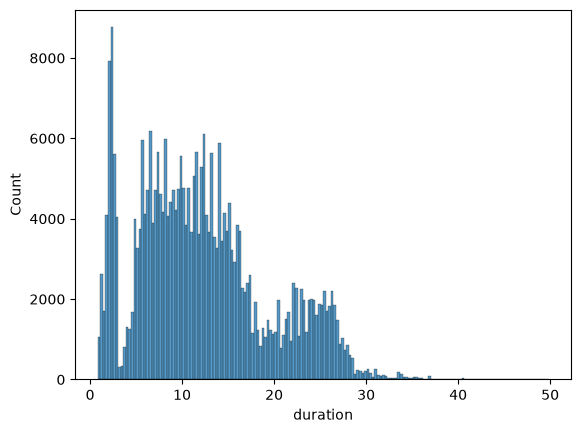

In [66]:
sns.histplot(data=data, x="duration")

In [ ]:
sns.histplot(data=data, x="days_left")

In [ ]:
sns.boxplot(data=data, x="duration")

<Axes: xlabel='days_left'>

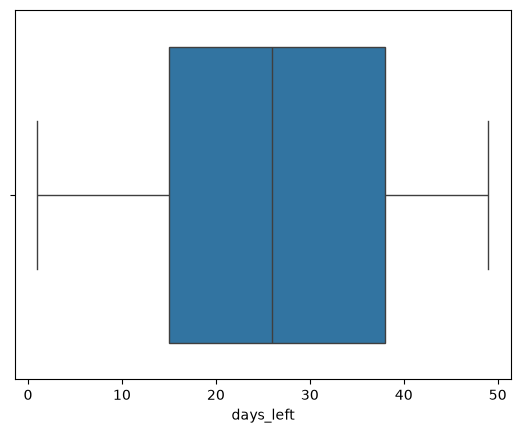

In [65]:
sns.boxplot(data=data, x="days_left")

Nous observons que les tickets à bas prix sont les plus nombreux, tandis que le nombre de tickets diminue lorsque le prix augmente

**Analyse des valeurs extrêmes (Outliers) :**

Les boîtes à moustaches (boxplots) montrent la présence de valeurs extrêmes. Pour la durée du vol (`duration`), on observe plusieurs vols exceptionnellement longs (au-delà de 30 heures). Pour les jours restants (`days_left`), il n'y a pas de valeurs extrêmes. Ces observations sont cruciales car elles peuvent impacter les modèles de prédiction.

***Analyse multivariée***

<Axes: xlabel='duration', ylabel='price'>

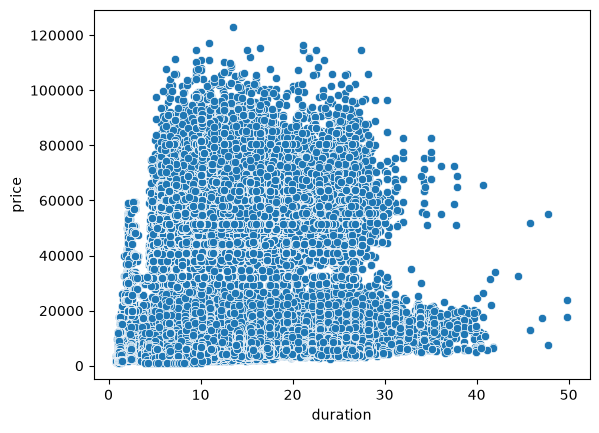

In [64]:
sns.scatterplot(data=data , x="duration" , y="price")

Nous observons que pour une même durée de vol, les prix peuvent être très différents. La durée seule ne semble donc pas expliquer fortement le prix

In [ ]:
sns.boxplot(
    data=data,
    x="class",
    y="price"
)

Nous observons une différence importante entre les prix des classes Economy et Business. Les billets Business ont généralement des prix plus élevés que les billets Economy

***correlation***

In [ ]:
corr = data.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True
)

La matrice de corrélation montre une faible corrélation positive entre la durée du vol et le prix (0,20), tandis que la corrélation entre days_left et le prix est très faible et négative (-0,092). La variable Unnamed: 0 doit être supprimée car elle correspond probablement à un index et n'est pas une caractéristique du vol

In [ ]:
variables_type = {
    "continue" : ["duration","days_left","price"],
    "descret" : ["airline" , "flight" , "source","city","departure_time","arrival_time","destination_city","class"]
}

le type variable de chaque column dans le dataset 

## Analyse univariée des variables catégorielles

In [ ]:
print(data["airline"].value_counts())
print(data["source_city"].value_counts())
print(data["departure_time"].value_counts())
print(data["stops"].value_counts())
print(data["arrival_time"].value_counts())
print(data["destination_city"].value_counts())
print(data["class"].value_counts())
print(data["flight"].nunique())

**Interprétation des variables catégorielles :**

- **Compagnies aériennes** : Vistara et Air India dominent largement le jeu de données en termes de nombre de vols proposés.
- **Villes** : Delhi et Mumbai sont les villes avec le plus fort trafic.
- **Temps de vol** : Les départs tôt le matin (Early_Morning) et le matin (Morning) sont les plus fréquents.
- **Escales** : La très grande majorité des vols comportent une seule escale (one).
- **Classe** : On note un fort déséquilibre entre les classes : la classe Economy représente la majorité écrasante des billets par rapport à la classe Business.

### graphs categorical variables 

In [ ]:
sns.countplot(data=data, x="airline")


In [ ]:
sns.countplot(data=data, x="class")

In [ ]:
sns.countplot(data=data, x="stops")

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=data, x="source_city", ax=axes[0, 0])
sns.countplot(data=data, x="destination_city", ax=axes[0, 1])
sns.countplot(data=data, x="departure_time", ax=axes[1, 0])
sns.countplot(data=data, x="arrival_time", ax=axes[1, 1])

plt.tight_layout()

### Multivariate Analysis

In [ ]:
sns.boxplot(
    data=data,
    x="airline",
    y="price"
)

**Interprétation (Compagnie aérienne et prix) :**

Vistara et Air India affichent les prix les plus élevés en moyenne, ce qui s'explique probablement par le fait qu'elles proposent des billets en classe Business. À l'inverse, AirAsia, Indigo, GO_FIRST et SpiceJet sont des compagnies low-cost avec des prix plus bas.

<Axes: xlabel='stops', ylabel='price'>

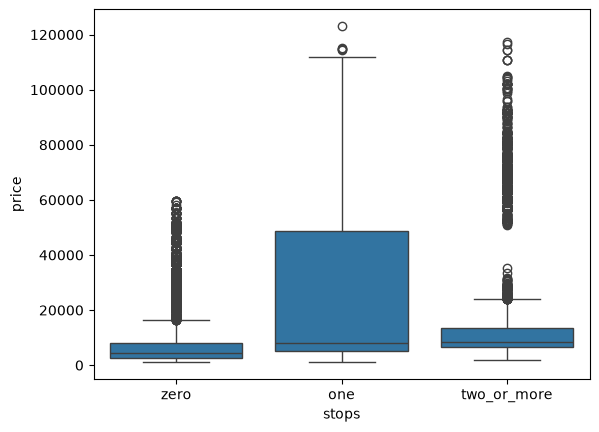

In [71]:
sns.boxplot(
    data=data,
    x="stops",
    y="price"
)

**Interprétation (Nombre d'escales et prix) :**

Les vols avec une escale (one) sont généralement plus chers que les vols directs (zero). Cela peut être dû au fait que les vols avec escale couvrent souvent de plus longues distances ou incluent des classes Business.

In [ ]:
sns.scatterplot(
    data=data,
    x="days_left",
    y="price"
)

<Axes: xlabel='days_left', ylabel='price'>

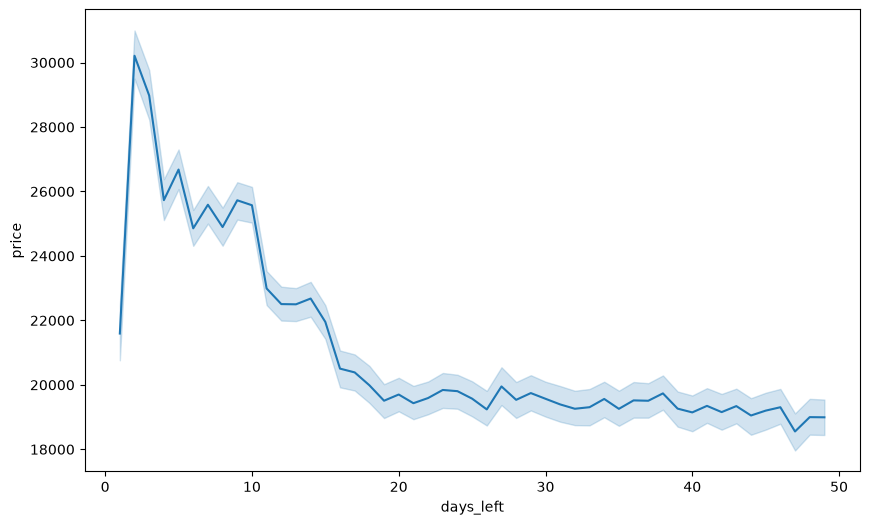

In [93]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.lineplot(data=data, x="days_left", y="price")

**Interprétation (Jours restants et prix) :**

Le graphique montre une tendance très claire : le prix des billets augmente considérablement à mesure que la date du vol approche (lorsque `days_left` diminue). Si l'on réserve 1 à 2 jours avant le départ, les prix atteignent leur maximum. En revanche, réserver plus de 15 jours à l'avance permet d'obtenir des prix plus bas.

### skewness

In [58]:
print("Skewness de duration :", data["duration"].skew())
print("Skewness de days_left :", data["days_left"].skew())
print("Skewness de price :", data["price"].skew())

Skewness de duration : 0.6028991297746271
Skewness de days_left : -0.035464349550665804
Skewness de price : 1.0613772532064343


Nous observons que la variable duration présente une asymétrie positive modérée, avec un Skewness de 0,603.

Nous observons que la variable days_left présente une distribution presque symétrique, avec un Skewness proche de 0 (-0,035).

Nous observons que la variable price présente une asymétrie positive, avec un Skewness de 1,061. Cela indique la présence de quelques valeurs de prix élevées qui étendent la distribution vers la droite.

***correlation***

<Axes: >

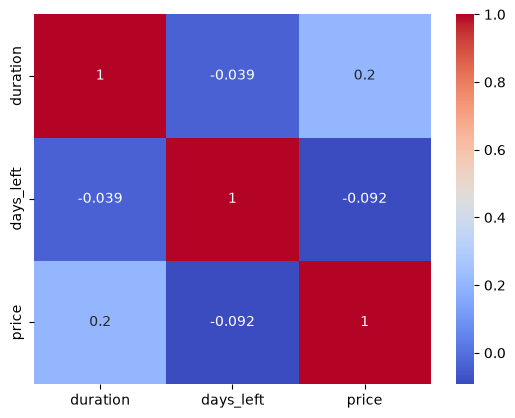

In [ ]:
corr = data.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

La variable Unnamed: 0 a été supprimée car elle correspond à un index et ne représente pas une caractéristique réelle du vol.

### Processing

***supprimer le column de unnamed: 0 et deviser les categorical et les numercal***

In [83]:
data = data.drop(columns=["Unnamed: 0"])

categorical_features = [
            "airline",
            "flight",
            "source_city",
            "departure_time",
            "stops",
            "arrival_time",
            "destination_city",
            "class"
        ]

numerical_features = [
            "duration",
            "days_left"
        ]



***deviser les features et le target ( cible )***

In [77]:
x = data.drop(columns=["price"])
y = data["price"]

print(x , y)

         airline   flight source_city departure_time stops   arrival_time  \
0       SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1       SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2        AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3        Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4        Vistara   UK-963       Delhi        Morning  zero        Morning   
...          ...      ...         ...            ...   ...            ...   
300148   Vistara   UK-822     Chennai        Morning   one        Evening   
300149   Vistara   UK-826     Chennai      Afternoon   one          Night   
300150   Vistara   UK-832     Chennai  Early_Morning   one          Night   
300151   Vistara   UK-828     Chennai  Early_Morning   one        Evening   
300152   Vistara   UK-822     Chennai        Morning   one        Evening   

       destination_city     class  duration  days_left  
0                M

***deviser les données à les données de train et les données de test***

In [80]:
X_train , X_test , y_train , y_test = train_test_split(
    x , y , test_size=0.2 , random_state=42
)

***encoding les columns categorial***

In [84]:
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)
X_train_encoded = encoder.fit_transform(
    X_train[categorical_features]
)
X_test_encoded = encoder.transform(
    X_test[categorical_features]
)


***transforme le resultat de ecoding à dataframe***

In [85]:
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(
        categorical_features
    ),
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(
        categorical_features
    ),
    index=X_test.index
)

print(X_train_encoded)

        airline_AirAsia  airline_Air_India  airline_GO_FIRST  airline_Indigo  \
148417              0.0                1.0               0.0             0.0   
36879               0.0                0.0               0.0             1.0   
274531              0.0                1.0               0.0             0.0   
166397              0.0                0.0               0.0             0.0   
272722              0.0                0.0               0.0             0.0   
...                 ...                ...               ...             ...   
119879              0.0                0.0               0.0             0.0   
259178              0.0                0.0               0.0             0.0   
131932              0.0                1.0               0.0             0.0   
146867              0.0                0.0               1.0             0.0   
121958              0.0                1.0               0.0             0.0   

        airline_SpiceJet  airline_Vista

***Ajouter les variables numériques***

In [87]:
X_train_final = pd.concat(
    [
        X_train[numerical_features],
        X_train_encoded
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        X_test[numerical_features],
        X_test_encoded
    ],
    axis=1
)

print(X_train_final , X_test_final)

        duration  days_left  airline_AirAsia  airline_Air_India  \
148417     19.42          6              0.0                1.0   
36879       7.00         13              0.0                0.0   
274531     21.17         44              0.0                1.0   
166397     10.25         11              0.0                0.0   
272722     26.50          5              0.0                0.0   
...          ...        ...              ...                ...   
119879     20.50          2              0.0                0.0   
259178     25.42          7              0.0                0.0   
131932     13.67         29              0.0                1.0   
146867      8.33         39              0.0                0.0   
121958     20.17         17              0.0                1.0   

        airline_GO_FIRST  airline_Indigo  airline_SpiceJet  airline_Vistara  \
148417               0.0             0.0               0.0              0.0   
36879                0.0             

***chose model for training***

In [88]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()


***training model linearregression***

In [89]:
model.fit(X_train_final , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1597,)","[ 56.56, -126.78, -1306.53,..., -182.84, 22423.87,-22423.87]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1597,)","['duration','days_left','airline_AirAsia',...,'destination_city_Mumbai', 'class_Business','class_Economy']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.025e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1597
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1584)


***test predesction***

In [ ]:
y_pred = model.predict(X_test_final)
comparaison = pd.DataFrame({
    "prix réel" : y_test.values,
    "prix prédict" : [int(x) for x in y_pred]
})

print(comparaison)



       prix réel  prix prédict
0           7366          6328
1          64831         56281
2           6195         12765
3          60160         53568
4           6578         11174
...          ...           ...
60026       5026          3719
60027       3001          3069
60028       6734          6092
60029       5082          3456
60030      66465         56066

[60031 rows x 2 columns]


***mesure le model***

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 4253.953718332661
RMSE: 6197.200686113572
R²  : 0.9254963782205883
